# 03 — Risk scoring and targeting

**Question answered here:** Q4, reframed.

## The reframe

The project set out to test whether the CRM team's auto-renew rule targets the wrong people. Notebook 02 
answered that: **it does not.** Auto-renew off churns at 41.2% against 4.7% for auto-renew on, and two 
thirds of that gap survives stratification by tenure and plan. The rule is sound.

What the rule cannot do is **prioritise**. It flags about 23,450 subscribers against a contact capacity of 
roughly 10,000. Some 57% of the flagged population goes uncontacted, currently on no principled basis.

> **The question is therefore: within the subscribers the rule already flags, which ~10,000 do we contact?**

## Pre-committed decision rules

| Rule | Value |
|---|---|
| Target population | `is_auto_renew == 0` only |
| Success metric | At-risk CLV captured at the contact cap |
| Model must beat best simple heuristic by | **10%** |
| If it does not | Recommend the heuristic and say so plainly |
| Behavioural features must beat account-only by | **5%** |
| If they do not | Recommend against building behavioural scoring infrastructure |
| AUC | Reported once, in a footnote |

Both thresholds are fixed here, before the models are built.


## 0. Setup


In [18]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

PROJECT = Path.cwd().parent
DB      = PROJECT / 'data' / 'kkbox.db'
EXPORTS = PROJECT / 'dashboard' / 'data'
EXPORTS.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

FX_NTD_PER_EUR   = 34.0
CONTACT_CAP_RATE = 0.05
COST_PER_CONTACT = 12.0
SAVE_UPLIFT      = 0.08
MARGIN           = 0.30

MODEL_UPLIFT_THRESHOLD      = 0.10   # model vs best heuristic
BEHAVIOUR_UPLIFT_THRESHOLD  = 0.05   # behaviour vs account-only
SEED = 42

conn = sqlite3.connect(DB)


In [19]:
raw = pd.read_sql('SELECT * FROM analysis_base', conn)

# Same exclusion policy as notebook 02 — data errors only.
raw = raw[(raw['payment_plan_days'] > 0) & ~(raw['tenure_days'] < 0)].copy()
print(f'cohort after exclusions: {len(raw):,}')

cohort_cap = int(len(raw) * CONTACT_CAP_RATE)
print(f'contact capacity        : {cohort_cap:,}')


cohort after exclusions: 199,980
contact capacity        : 9,999


## 1. Customer value, recomputed here

CLV is derived per tenure band from the **full cohort**, not from the target population. Using the 
auto-renew-off group's own churn rate would understate expected lifetime for exactly the subscribers 
being valued.


In [20]:
econ = (raw.groupby('tenure_band')
           .agg(churn_rate  = ('is_churn', 'mean'),
                amount_paid = ('actual_amount_paid', 'mean'))
           .reset_index())
econ['expected_cycles'] = 1 / econ['churn_rate']
econ['clv_ntd'] = econ['expected_cycles'] * econ['amount_paid'] * MARGIN
econ['clv_eur'] = econ['clv_ntd'] / FX_NTD_PER_EUR

raw['clv_ntd'] = raw['tenure_band'].map(econ.set_index('tenure_band')['clv_ntd'])
raw['clv_eur'] = raw['clv_ntd'] / FX_NTD_PER_EUR

econ[['tenure_band', 'churn_rate', 'expected_cycles', 'clv_eur']].round(3)


,tenure_band,churn_rate,expected_cycles,clv_eur
0,01 0-3 months,0.097,10.349,10.801
1,02 3-6 months,0.083,12.090,13.899
2,03 6-12 months,0.082,12.150,14.121
3,04 1-2 years,0.090,11.134,14.450
4,05 2+ years,0.099,10.081,15.157
5,99 unknown,0.053,18.845,18.371


## 2. The target population

Everything from here runs on `is_auto_renew == 0` only. The model is not asked to rediscover a rule the 
business already applies — it is asked to order the list that rule produces.


In [21]:
target = raw[raw['is_auto_renew'] == 0].copy()

cap = min(cohort_cap, len(target))

print(f'flagged by the rule     : {len(target):,}')
print(f'contact capacity        : {cap:,}')
print(f'coverage                : {cap / len(target):.1%}')
print(f'churn rate within group : {target["is_churn"].mean():.2%}')
print()
print(f'total at-risk CLV in group : '
      f'\u20ac{(target["is_churn"] * target["clv_ntd"]).sum() / FX_NTD_PER_EUR:,.0f}')
print(f'perfect-foresight ceiling  : the most any targeting method could capture')


flagged by the rule     : 23,452
contact capacity        : 9,999
coverage                : 42.6%
churn rate within group : 41.19%

total at-risk CLV in group : €140,551
perfect-foresight ceiling  : the most any targeting method could capture


### 2a. What plan length is really telling us

`payment_plan_days` carries more model gain than every behavioural feature combined, so it is worth knowing
what it keys on before trusting a ranking built on it.


In [22]:
(target.groupby('plan_band')
       .agg(n=('is_churn', 'size'),
            churn=('is_churn', 'mean'),
            free_share=('plan_list_price', lambda x: (x == 0).mean()),
            median_price=('actual_amount_paid', 'median'))
       .round(3))


,n,churn,free_share,median_price
plan_band,,,,
01 weekly or less,136,0.757,0.882,0.0
02 monthly,18194,0.291,0.001,149.0
03 quarterly,1036,0.764,0.199,447.0
04 half-year,2168,0.842,0.044,894.0
05 annual or longer,1918,0.859,0.076,1788.0


### 2b. CLV, recomputed by plan band

The diagnostic above shows that within this population, anything longer than a monthly plan churns at
76-86% against 29% for monthly — and these are not free-plan artefacts (median NT$447 to NT$1,788).

**A long-duration plan with auto-renew switched off is a prepaid block purchase, not a subscription.**
Someone buying 180 days upfront without auto-renew is buying a quantity of time; when it runs out they do
not renew, and the product worked exactly as sold.

That makes a tenure-based CLV the wrong denominator here. Value per cycle spans roughly 12x across plan
bands and renewal propensity moves with it, so CLV is recomputed on plan band **before** any targeting
method is evaluated. Ranking by model score x a flat CLV would otherwise order the list on a number that
does not describe these subscribers.


In [23]:
econ_plan = (target.groupby('plan_band')
                   .agg(churn_rate  = ('is_churn', 'mean'),
                        amount_paid = ('actual_amount_paid', 'mean'),
                        subscribers = ('is_churn', 'size'))
                   .reset_index())

econ_plan['expected_cycles'] = 1 / econ_plan['churn_rate']
econ_plan['clv_ntd'] = econ_plan['expected_cycles'] * econ_plan['amount_paid'] * MARGIN
econ_plan['clv_eur'] = econ_plan['clv_ntd'] / FX_NTD_PER_EUR

print('CLV by plan band, within the target population:')
print(econ_plan.round(2).to_string(index=False))

# Overwrite the tenure-based CLV for this population only.
clv_map = econ_plan.set_index('plan_band')['clv_ntd']
target['clv_ntd'] = target['plan_band'].map(clv_map)
target['clv_eur'] = target['clv_ntd'] / FX_NTD_PER_EUR

at_risk_total = (target['is_churn'] * target['clv_ntd']).sum() / FX_NTD_PER_EUR
print()
print(f'at-risk CLV, tenure-based (previous) : \u20ac140,551')
print(f'at-risk CLV, plan-based   (correct)  : \u20ac{at_risk_total:,.0f}')
print()
print('The earlier figure overstated the prize by roughly 5x. Every economic')
print('claim downstream now rests on the plan-based number.')


CLV by plan band, within the target population:
          plan_band  churn_rate  amount_paid  subscribers  expected_cycles  clv_ntd  clv_eur
  01 weekly or less        0.76         4.12          136             1.32     1.63     0.05
         02 monthly        0.29       160.85        18194             3.44   165.94     4.88
       03 quarterly        0.76       305.43         1036             1.31   119.86     3.53
       04 half-year        0.84       708.46         2168             1.19   252.34     7.42
05 annual or longer        0.86      1619.88         1918             1.16   565.58    16.63

at-risk CLV, tenure-based (previous) : €140,551
at-risk CLV, plan-based   (correct)  : €69,586

The earlier figure overstated the prize by roughly 5x. Every economic
claim downstream now rests on the plan-based number.


## 3. Leakage audit

Run **before** any model is fitted. Two questions: could each feature have been computed before the 
subscriber's expiry date, and would CRM actually have it at decision time?

| Check | Status |
|---|---|
| No feature derived from `membership_expire_date` arithmetic | enforced in `sql/01` |
| No transaction dated at or after expiry | enforced in `sql/01` anchor filter |
| No log data dated at or after expiry | enforced in `sql/02` window join |
| No feature encoding the renewal event | `is_churn` is the only outcome column, and it is the label |
| `cancel_before_expiry` is pre-expiry | yes — a cancellation is not a renewal outcome |
| Per-feature correlation reviewed | below |


In [24]:
ACCOUNT_FEATURES = [
    'tenure_days', 'tenure_months', 'payment_plan_days', 'payment_method_id',
    'cancel_before_expiry', 'plan_list_price', 'actual_amount_paid',
    'monthly_arpu_ntd', 'discount_depth', 'prior_tx_count', 'prior_cancel_count',
    'prior_discounted_tx', 'prior_distinct_plans', 'city', 'registered_via',
    'gender', 'age', 'age_stated', 'tenure_band',
]

BEHAVIOUR_FEATURES = [
    'has_logs_30d', 'active_days_30d', 'active_day_rate_30d', 'total_hours_30d',
    'unique_tracks_30d', 'plays_total_30d', 'plays_100_30d',
    'completion_ratio_30d', 'skip_ratio_30d', 'mins_per_active_day_30d',
    'days_since_last_play', 'recent_active_days', 'baseline_active_days',
    'active_day_trend_ratio', 'hours_trend_ratio', 'engagement_trend',
]

# is_auto_renew is constant within the target population, so it carries no information here.
assert target['is_auto_renew'].nunique() == 1

ALL_FEATURES = ACCOUNT_FEATURES + BEHAVIOUR_FEATURES
print(f'{len(ACCOUNT_FEATURES)} account features, {len(BEHAVIOUR_FEATURES)} behavioural')


19 account features, 16 behavioural


In [25]:
# Anything correlating suspiciously hard with the label gets investigated, not celebrated.
num = [c for c in ALL_FEATURES if pd.api.types.is_numeric_dtype(target[c])]
corr = (target[num + ['is_churn']].corr()['is_churn']
        .drop('is_churn').sort_values(key=abs, ascending=False))

print('strongest absolute correlations with the label:')
print(corr.head(12).round(4))
print()
suspicious = corr[corr.abs() > 0.7]
if len(suspicious):
    print('INVESTIGATE — correlation above 0.7 suggests leakage:')
    print(suspicious)
else:
    print('No feature exceeds |r| = 0.7. Consistent with no leakage.')


strongest absolute correlations with the label:
payment_plan_days       0.3842
actual_amount_paid      0.3466
plan_list_price         0.3466
monthly_arpu_ntd       -0.3068
prior_tx_count         -0.2839
payment_method_id      -0.2222
active_days_30d        -0.2165
active_day_rate_30d    -0.2165
recent_active_days     -0.2102
baseline_active_days   -0.1533
days_since_last_play    0.1475
prior_distinct_plans   -0.1422
Name: is_churn, dtype: float64

No feature exceeds |r| = 0.7. Consistent with no leakage.


## 4. Prepare the modelling frame


In [26]:
CATEGORICAL = ['gender', 'engagement_trend', 'tenure_band']

X = target[ALL_FEATURES].copy()
for c in CATEGORICAL:
    X[c] = X[c].astype('category')
y = target['is_churn'].astype(int)

idx_train, idx_test = train_test_split(
    target.index, test_size=0.30, stratify=y, random_state=SEED)

test_cap = int(round(cap * len(idx_test) / len(target)))

print(f'train {len(idx_train):,} | test {len(idx_test):,}')
print(f'contact cap scaled to the test set: {test_cap:,}')
print(f'churn rate  train {y.loc[idx_train].mean():.2%} | test {y.loc[idx_test].mean():.2%}')


train 16,416 | test 7,036
contact cap scaled to the test set: 3,000
churn rate  train 41.19% | test 41.19%


## 5. Two models

Account-only first, then account plus behaviour. The difference between them is the direct test of whether 
behavioural scoring is worth building — the question notebook 02 raised and could not settle.


In [28]:
def fit(features, name):
    params = dict(objective='binary', learning_rate=0.05, num_leaves=31,
                  min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, n_estimators=400,
                  random_state=SEED, verbose=-1)
    m = lgb.LGBMClassifier(**params)
    m.fit(X.loc[idx_train, features], y.loc[idx_train],
          eval_set=[(X.loc[idx_test, features], y.loc[idx_test])],
          eval_metric='auc',
          callbacks=[lgb.early_stopping(40, verbose=False)])
    p = m.predict_proba(X.loc[idx_test, features])[:, 1]
    auc = roc_auc_score(y.loc[idx_test], p)
    print(f'{name:<22} AUC {auc:.4f}   (footnote only)')
    return m, p, auc


m_acct, p_acct, auc_acct = fit(ACCOUNT_FEATURES, 'account only')
m_full, p_full, auc_full = fit(ALL_FEATURES,     'account + behaviour')


/Users/laxmigupte/anaconda3/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


account only           AUC 0.7636   (footnote only)


/Users/laxmigupte/anaconda3/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


account + behaviour    AUC 0.7962   (footnote only)


## 6. The evaluation that matters

Not AUC. The business question is: **given capacity for N contacts, how much at-risk CLV does each 
targeting method reach?** Four contenders, all restricted to the same population and the same N.

- **random** — the status quo when the rule over-produces and someone picks arbitrarily
- **CLV-ranked** — contact the most valuable first, ignoring risk
- **engagement-ranked** — fewest active days first, the intuitive behavioural heuristic
- **model score x CLV** — expected value at risk


In [29]:
ev = target.loc[idx_test, ['is_churn', 'clv_ntd', 'active_days_30d',
                           'days_since_last_play', 'tenure_band']].copy()
ev['p_acct'] = p_acct
ev['p_full'] = p_full
ev['at_risk_value'] = ev['is_churn'] * ev['clv_ntd']

total_at_risk = ev['at_risk_value'].sum()


def captured(order_col, ascending=False, label=''):
    picked = ev.sort_values(order_col, ascending=ascending).head(test_cap)
    val = picked['at_risk_value'].sum()
    return {
        'method':            label,
        'contacted':         len(picked),
        'churners_reached':  int(picked['is_churn'].sum()),
        'precision':         picked['is_churn'].mean(),
        'at_risk_eur':       val / FX_NTD_PER_EUR,
        'pct_of_ceiling':    100 * val / total_at_risk,
    }


rng = np.random.default_rng(SEED)
ev['random'] = rng.random(len(ev))
ev['expected_value_acct'] = ev['p_acct'] * ev['clv_ntd']
ev['expected_value_full'] = ev['p_full'] * ev['clv_ntd']

comparison = pd.DataFrame([
    captured('random',              False, 'random within rule'),
    captured('clv_ntd',             False, 'CLV-ranked'),
    captured('active_days_30d',     True,  'fewest active days'),
    captured('days_since_last_play', False, 'most days since last play'),
    captured('expected_value_acct', False, 'model: account only'),
    captured('expected_value_full', False, 'model: account + behaviour'),
])

comparison['vs_random'] = (comparison['at_risk_eur']
                           / comparison.loc[0, 'at_risk_eur'] - 1)
comparison.round(3)


,method,contacted,churners_reached,precision,at_risk_eur,pct_of_ceiling,vs_random
0,random within rule,3000,1239,0.413,9154.082,43.335,0.000
1,CLV-ranked,3000,1585,0.528,15151.542,71.726,0.655
2,fewest active days,3000,1487,0.496,10809.937,51.173,0.181
3,most days since last play,3000,1385,0.462,9787.431,46.333,0.069
4,model: account only,3000,1914,0.638,16452.298,77.884,0.797
5,model: account + behaviour,3000,2004,0.668,16896.963,79.989,0.846


### 6a. The two pre-committed decisions


In [30]:
best_heuristic = comparison.iloc[:4]['at_risk_eur'].max()
best_heuristic_name = comparison.iloc[:4].set_index('method')['at_risk_eur'].idxmax()
model_value = comparison.loc[5, 'at_risk_eur']
acct_value  = comparison.loc[4, 'at_risk_eur']

model_uplift     = model_value / best_heuristic - 1
behaviour_uplift = model_value / acct_value - 1

print(f'best heuristic          : {best_heuristic_name} (\u20ac{best_heuristic:,.0f})')
print(f'full model              : \u20ac{model_value:,.0f}')
print(f'uplift over heuristic   : {model_uplift:+.1%}  '
      f'(threshold {MODEL_UPLIFT_THRESHOLD:.0%})')
print()
print(f'account-only model      : \u20ac{acct_value:,.0f}')
print(f'behaviour adds          : {behaviour_uplift:+.1%}  '
      f'(threshold {BEHAVIOUR_UPLIFT_THRESHOLD:.0%})')
print()
print('=' * 62)
if model_uplift >= MODEL_UPLIFT_THRESHOLD:
    print('DECISION: deploy the model. It clears the 10% bar.')
else:
    print(f'DECISION: keep the simple rule \u2014 rank by {best_heuristic_name}.')
    print('The model does not clear the 10% bar. Report this, do not bury it.')
print()
if behaviour_uplift >= BEHAVIOUR_UPLIFT_THRESHOLD:
    print('DECISION: behavioural features earn their place.')
else:
    print('DECISION: do NOT build behavioural scoring infrastructure.')
    print('Account attributes already in the billing table do the work.')
print('=' * 62)


best heuristic          : CLV-ranked (€15,152)
full model              : €16,897
uplift over heuristic   : +11.5%  (threshold 10%)

account-only model      : €16,452
behaviour adds          : +2.7%  (threshold 5%)

DECISION: deploy the model. It clears the 10% bar.

DECISION: do NOT build behavioural scoring infrastructure.
Account attributes already in the billing table do the work.


### 6d. Does the campaign actually pay for itself?

The targeting question and the spend question are separate. A better-ordered list is worth having only if
the campaign clears its own cost, and the plan-based CLV is roughly a fifth of what the earlier figure
implied. This is the number Finance will ask for first.


In [31]:
scale = len(target) / len(idx_test)     # test set back up to the full flagged population

rows = []
for _, r in comparison.iterrows():
    reached_value = r['at_risk_eur'] * scale
    saves         = r['churners_reached'] * scale * SAVE_UPLIFT
    value_saved   = saves * (reached_value / max(r['churners_reached'] * scale, 1))
    cost          = cap * COST_PER_CONTACT / FX_NTD_PER_EUR
    rows.append({
        'method':        r['method'],
        'contacts':      cap,
        'cost_eur':      round(cost, 0),
        'saves':         round(saves, 0),
        'value_saved':   round(value_saved, 0),
        'net_eur':       round(value_saved - cost, 0),
        'roi':           round(value_saved / cost, 2),
    })

roi = pd.DataFrame(rows)
print(roi.to_string(index=False))
print()

best = roi.loc[roi['roi'].idxmax()]
print('=' * 62)
if best['roi'] < 1:
    print(f'DECISION: the campaign does NOT pay back at NT${COST_PER_CONTACT:.0f} per contact.')
    print(f'Best method returns {best["roi"]:.2f}x. Recommend narrowing to the highest-CLV')
    print('segment, or renegotiating cost per contact, rather than running it as scoped.')
else:
    print(f'DECISION: campaign pays back at {best["roi"]:.2f}x using {best["method"]}.')
print('=' * 62)
print()
print('Breakeven cost per contact (NT$), by method:')
for _, r in roi.iterrows():
    print(f'  {r["method"]:<30} {r["value_saved"] / cap * FX_NTD_PER_EUR:>7.2f}')


                    method  contacts  cost_eur  saves  value_saved  net_eur  roi
        random within rule      9999    3529.0  330.0       2441.0  -1088.0 0.69
                CLV-ranked      9999    3529.0  423.0       4040.0    511.0 1.14
        fewest active days      9999    3529.0  397.0       2882.0   -647.0 0.82
 most days since last play      9999    3529.0  369.0       2610.0   -919.0 0.74
       model: account only      9999    3529.0  510.0       4387.0    858.0 1.24
model: account + behaviour      9999    3529.0  534.0       4506.0    977.0 1.28

DECISION: campaign pays back at 1.28x using model: account + behaviour.

Breakeven cost per contact (NT$), by method:
  random within rule                8.30
  CLV-ranked                       13.74
  fewest active days                9.80
  most days since last play         8.87
  model: account only              14.92
  model: account + behaviour       15.32


### 6b. The chart that justifies the budget

Cumulative at-risk value captured as contact volume rises. The vertical line is actual capacity — only 
the value to the left of it is reachable.


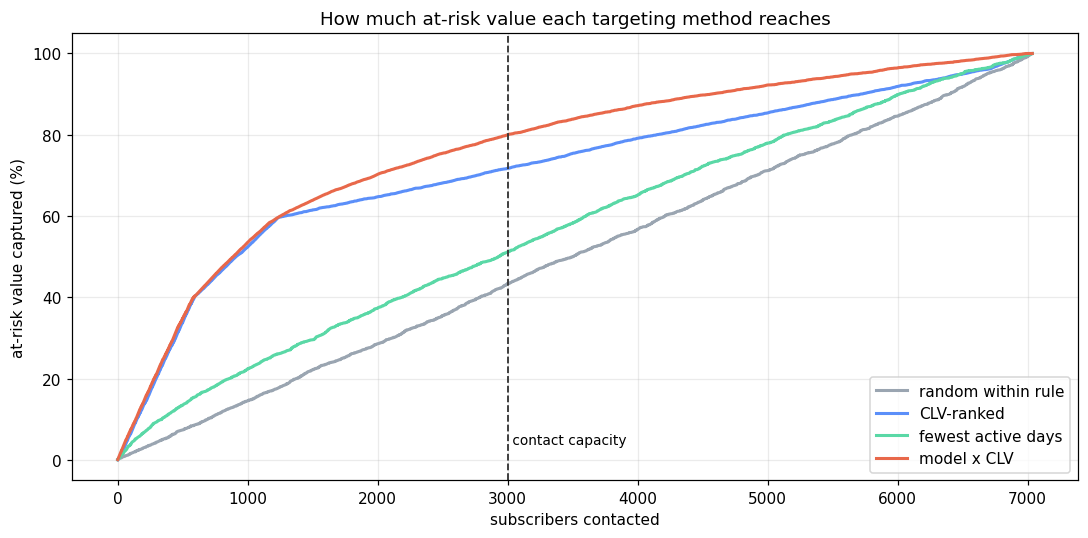

In [32]:
fig, ax = plt.subplots()

curves = [('random',              False, 'random within rule',   '#9AA5B1'),
          ('clv_ntd',             False, 'CLV-ranked',           '#5B8FF9'),
          ('active_days_30d',     True,  'fewest active days',   '#5AD8A6'),
          ('expected_value_full', False, 'model x CLV',          '#E8684A')]

for col, asc, label, colour in curves:
    s = ev.sort_values(col, ascending=asc)
    cum = s['at_risk_value'].cumsum() / total_at_risk * 100
    ax.plot(np.arange(1, len(s) + 1), cum.values, label=label,
            linewidth=2, color=colour)

ax.axvline(test_cap, linestyle='--', color='#333', linewidth=1.2)
ax.text(test_cap, 4, ' contact capacity', fontsize=9)
ax.set_xlabel('subscribers contacted')
ax.set_ylabel('at-risk value captured (%)')
ax.set_title('How much at-risk value each targeting method reaches')
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PROJECT / 'images' / 'value_capture_curve.png', dpi=150, bbox_inches='tight')
plt.show()


### 6c. Decile lift


In [33]:
ev['decile'] = pd.qcut(ev['p_full'].rank(method='first', ascending=False),
                       10, labels=range(1, 11)).astype(int)

lift = (ev.groupby('decile')
          .agg(subscribers = ('is_churn', 'size'),
               churners    = ('is_churn', 'sum'),
               churn_rate  = ('is_churn', 'mean'),
               at_risk_eur = ('at_risk_value', lambda s: s.sum() / FX_NTD_PER_EUR))
          .reset_index())
lift['lift_vs_random'] = lift['churn_rate'] / ev['is_churn'].mean()
lift.round(3)


,decile,subscribers,churners,churn_rate,at_risk_eur,lift_vs_random
0,1,704,645,0.916,6924.795,2.224
1,2,704,591,0.839,5901.106,2.038
2,3,703,409,0.582,2186.453,1.413
3,4,704,295,0.419,1436.527,1.017
4,5,703,253,0.360,1234.595,0.874
5,6,704,193,0.274,941.935,0.666
6,7,703,149,0.212,727.193,0.515
7,8,704,133,0.189,649.105,0.459
8,9,703,124,0.176,605.181,0.428
9,10,704,106,0.151,517.332,0.366


## 7. What the model actually keys on

Feature importance read as diagnosis, not as a result. The question is whether the model found something 
a human could act on, or whether it is redistributing noise.


In [34]:
imp = (pd.DataFrame({'feature': ALL_FEATURES,
                     'gain': m_full.booster_.feature_importance('gain')})
       .sort_values('gain', ascending=False))
imp['share'] = 100 * imp['gain'] / imp['gain'].sum()
imp['kind'] = np.where(imp['feature'].isin(BEHAVIOUR_FEATURES),
                       'behaviour', 'account')

print('share of total gain by feature type:')
print(imp.groupby('kind')['share'].sum().round(1))
print()
imp.head(15).round(2)


share of total gain by feature type:
kind
account      65.5
behaviour    34.5
Name: share, dtype: float64



,feature,gain,share,kind
2,payment_plan_days,25653.47,41.01,account
7,monthly_arpu_ntd,4419.13,7.06,account
31,baseline_active_days,4352.49,6.96,behaviour
9,prior_tx_count,3191.72,5.10,account
32,active_day_trend_ratio,2514.00,4.02,behaviour
33,hours_trend_ratio,2102.42,3.36,behaviour
30,recent_active_days,1834.33,2.93,behaviour
0,tenure_days,1592.70,2.55,account
26,completion_ratio_30d,1592.25,2.55,behaviour
29,days_since_last_play,1443.19,2.31,behaviour


## 8. Export the scored list for the Streamlit planner

A sample of the scored target population, with everything the planner needs and nothing it does not. 
Subscriber IDs are dropped — the tool demonstrates the decision logic, not the identities.


In [35]:
scored = ev.copy()
scored['risk_score'] = scored['p_full']
scored['clv_eur']    = scored['clv_ntd'] / FX_NTD_PER_EUR
scored['expected_value_eur'] = scored['risk_score'] * scored['clv_eur']

out = (scored[['risk_score', 'clv_eur', 'expected_value_eur', 'is_churn',
               'tenure_band', 'active_days_30d', 'days_since_last_play']]
       .sample(n=min(5000, len(scored)), random_state=SEED)
       .reset_index(drop=True)
       .round(4))

out.to_csv(EXPORTS / 'scored_sample.csv', index=False)
comparison.to_csv(EXPORTS / 'targeting_comparison.csv', index=False)
lift.to_csv(EXPORTS / 'decile_lift.csv', index=False)

print(f'wrote {len(out):,} scored rows and 2 evaluation tables')
out.head()


wrote 5,000 scored rows and 2 evaluation tables


,risk_score,clv_eur,expected_value_eur,is_churn,tenure_band,active_days_30d,days_since_last_play
0,0.6665,16.6348,11.0879,0,05 2+ years,19,1.0
1,0.1956,4.8805,0.9547,0,04 1-2 years,30,1.0
2,0.2145,4.8805,1.0471,0,05 2+ years,15,1.0
3,0.4781,4.8805,2.3335,0,05 2+ years,17,1.0
4,0.3691,4.8805,1.8012,0,04 1-2 years,28,1.0


## 9. Findings

| # | Finding | Your number |
|---|---|---|
| 1 | At-risk CLV in the flagged population | |
| 2 | Coverage: capacity as a share of the flagged population | |
| 3 | Best simple heuristic, and what it captures | |
| 4 | Model uplift over that heuristic, against the 10% bar | |
| 5 | What behaviour adds over account-only, against the 5% bar | |
| 6 | Share of model gain coming from behavioural features | |
| 7 | Top decile lift | |

### If the model did not clear the bar

Say so, in the deck, on its own slide. A negative result that was pre-registered and honestly reported is 
stronger evidence of judgment than a model that squeaked past a threshold you moved afterwards. The 
recommendation becomes: rank the flagged list by the winning heuristic, skip the scoring pipeline, and 
spend the engineering time on the holdout test instead.

### Decision log entries

- Model restricted to the auto-renew-off population, and why
- CLV derived from full-cohort tenure bands rather than the target group's own rate
- Both uplift thresholds fixed before fitting; the outcome either way


In [36]:
conn.close()
print('done \u2014 next: Tableau dashboard, then the deck')


done — next: Tableau dashboard, then the deck
